In [4]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from physics.heat_flux_model import demo_heat_pulse
from optics.optical_system import *
import matplotlib.pyplot as plt

## Generate thermal history

In [5]:
data = demo_heat_pulse()

T = data["T"]
q_rad = data["q_rad"]
t = data["t"]

## Compute collected power:

In [6]:
lens = 0.025      # 25 mm lens
distance = 2.0    # 2 m from divertor
area = 0.01       # 10 cm × 10 cm tile

throughput = optical_throughput()

In [7]:
P = collected_power(
    q_rad,
    area,
    lens,
    distance,
    throughput
)

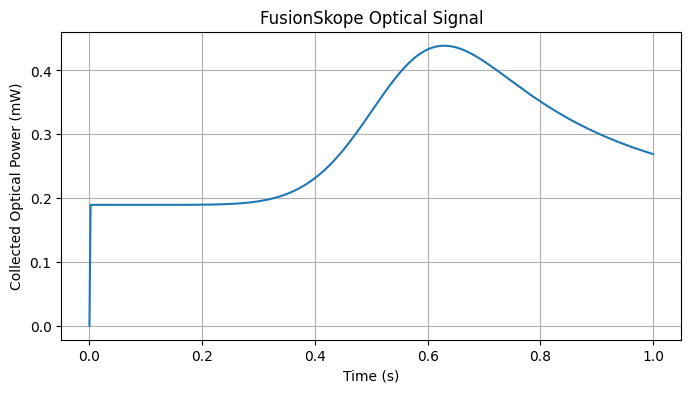

In [9]:
plt.figure(figsize=(8,4))

plt.plot(t,P*1000)

plt.xlabel("Time (s)")
plt.ylabel("Collected Optical Power (mW)")
plt.title("FusionSkope Optical Signal")

plt.grid(True)

### Once we know how much optical power reaches the camera, the next question is:

## Can the detector measure it?

That leads naturally to a **Sensor Model**, where I'd include:

* Quantum efficiency (wavelength-dependent)
* Pixel size and field of view
* Exposure time
* Shot noise
* Read noise
* Full-well capacity
* Dynamic range
* Signal-to-noise ratio (SNR)

At that point, it should be possible to answer engineering questions like:

* Is a CMOS sensor sufficient, or is (e.g.) an InGaAs detector needed?
* Will the camera saturate during a 10 MW/m² divertor event?
* What exposure time is required to resolve transient hot spots?
* What lens aperture provides the best compromise between signal and depth of field?